In [28]:
import tensorflow as tf
import time
import numpy as np
import os
import pickle5 as pickle
import argparse
import utilityarm as utility
import pandas as pd
from sklearn.metrics import *

In [29]:
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior() 

class BPR:

    def __init__(self, sess, dict_args, train_df, vali_df
                 , key_type, user_type_list, item_type_count):
       
        self.dataname = dict_args['dataname']

        self.key_type = key_type
        self.user_type_list = user_type_list
        self.item_type_count = item_type_count

        self.sess = sess
        #self.args = args

        self.num_cols = len(train_df['item_id'].unique())
        self.num_rows = len(train_df['user_id'].unique())

        self.hidden_neuron = dict_args['hidden_neuron']
        self.neg = dict_args['neg']
        self.batch_size = dict_args['batch_size']

        self.train_df = train_df
        self.vali_df = vali_df
        self.num_train = len(self.train_df)
        self.num_vali = len(self.vali_df)

        self.train_epoch = dict_args['train_epoch']

        self.lr = dict_args['lr'] # learning rate
        self.optimizer_method = dict_args['optimizer_method']
        self.display_step = dict_args['display_step']

        #self.num_genre = dict_args['num_type']

        self.reg = dict_args['reg'] # regularization term trade-off

        print('**********BPR**********')
        #print(self.args)
        self._prepare_model()

    def run(self):
        init = tf.global_variables_initializer()
        self.sess.run(init)
        for epoch_itr in range(1, self.train_epoch + 1):
            self.train_model(epoch_itr)
            if epoch_itr % self.display_step == 0:
                self.test_model(epoch_itr)
        return self.make_records()

    def _prepare_model(self):
        with tf.name_scope("input_data"):
            self.user_input = tf.placeholder(tf.int32, shape=[None, 1], name="user_input")
            self.item_input_pos = tf.placeholder(tf.int32, shape=[None, 1], name="item_input_pos")
            self.item_input_neg = tf.placeholder(tf.int32, shape=[None, 1], name="item_input_neg")

        with tf.variable_scope("BPR", reuse=tf.AUTO_REUSE):
            self.P = tf.get_variable(name="P", initializer=tf.truncated_normal(shape=[self.num_rows, self.hidden_neuron],
                                                                          mean=0, stddev=0.03), dtype=tf.float32)
            self.Q = tf.get_variable(name="Q", initializer=tf.truncated_normal(shape=[self.num_cols+1, self.hidden_neuron],
                                                                          mean=0, stddev=0.03), dtype=tf.float32)

        self.saver = tf.train.Saver([self.P, self.Q])

        p = tf.reduce_sum(tf.nn.embedding_lookup(self.P, self.user_input), 1)
        q_neg = tf.reduce_sum(tf.nn.embedding_lookup(self.Q, self.item_input_neg), 1)
        q_pos = tf.reduce_sum(tf.nn.embedding_lookup(self.Q, self.item_input_pos), 1)

        predict_pos = (tf.reduce_sum(p * q_pos, 1))
        predict_neg = (tf.reduce_sum(p * q_neg, 1))

        cost1 = tf.reduce_sum(tf.nn.softplus(-(predict_pos - predict_neg)))
        cost2 = self.reg * 0.5 * (self.l2_norm(self.P) + self.l2_norm(self.Q))  # regularization term

        self.cost = cost1 + cost2  # the loss function

        if self.optimizer_method == "Adam":
            optimizer = tf.train.AdamOptimizer(self.lr)
        elif self.optimizer_method == "Adadelta":
            optimizer = tf.train.AdadeltaOptimizer(self.lr)
        elif self.optimizer_method == "Adagrad":
            optimizer = tf.train.AdadeltaOptimizer(self.lr)
        elif self.optimizer_method == "RMSProp":
            optimizer = tf.train.RMSPropOptimizer(self.lr)
        elif self.optimizer_method == "GradientDescent":
            optimizer = tf.train.GradientDescentOptimizer(self.lr)
        elif self.optimizer_method == "Momentum":
            optimizer = tf.train.MomentumOptimizer(self.lr, 0.9)
        else:
            raise ValueError("Optimizer Key ERROR")

        with tf.variable_scope("Optimizer", reuse=tf.AUTO_REUSE):
            self.optimizer = optimizer.minimize(self.cost)

    def train_model(self, itr):
        NS_start_time = time.time() * 1000.0
        epoch_cost = 0
        num_sample, user_list, item_pos_list, item_neg_list = utility.negative_sample(self.train_df, self.num_rows,
                                                                                      self.num_cols, self.neg)
        NS_end_time = time.time() * 1000.0

        start_time = time.time() * 1000.0
        num_batch = int(len(user_list) / float(self.batch_size)) + 1
        random_idx = np.random.permutation(len(user_list))
        for i in range(num_batch):

            # get the indices of the current batch
            if i == num_batch - 1:
                batch_idx = random_idx[i * self.batch_size:]
            elif i < num_batch - 1:
                batch_idx = random_idx[(i * self.batch_size):((i + 1) * self.batch_size)]
            _, tmp_cost = self.sess.run(  # do the optimization by the minibatch
                [self.optimizer, self.cost],
                feed_dict={self.user_input: user_list[batch_idx, :],
                           self.item_input_pos: item_pos_list[batch_idx, :],
                           self.item_input_neg: item_neg_list[batch_idx, :]})
            epoch_cost += tmp_cost

        if itr % self.display_step == 0:
            print ("Training //", "Epoch %d //" % itr, " Total cost = {:.5f}".format(epoch_cost),
                   "Training time : %d ms" % (time.time() * 1000.0 - start_time),
                   "negative Sampling time : %d ms" % (NS_end_time - NS_start_time),
                   "negative samples : %d" % (num_sample))

        ckpt_save_path = "./"+self.dataname+"/BPR_check_points"
        if not os.path.exists(ckpt_save_path):
            os.makedirs(ckpt_save_path)
        self.saver.save(sess, ckpt_save_path + "/check_point.ckpt", global_step=itr)

    def test_model(self, itr):  # calculate the cost and rmse of testing set in each epoch
        if itr % self.display_step == 0:
            start_time = time.time() * 1000.0
            P, Q = self.sess.run([self.P, self.Q])
            Rec = np.matmul(P, Q.T)

            [precision, recall, f_score, NDCG] = utility.test_model_all(Rec, self.vali_df, self.train_df)
#             utility.ranking_analysis(Rec, self.vali_df, self.train_df, self.key_type, self.user_type_list,
#                                      self.item_type_count)
            utility.test_model_per_user_type(Rec, self.vali_df, self.train_df, self.user_type_list, self.key_type)
            auc_global = utility.auc_per_user(Rec, self.vali_df, self.train_df)

            print("AUC global is: ", auc_global)
            
#             for k in self.key_type:
#                 print("AUC per %d is:\t[%.7f] "%(k, auc[k]))
#             print("AUC global is: ", auc_global)
            print (
                "Testing //", "Epoch %d //" % itr,
                "Testing time : %d ms" % (time.time() * 1000.0 - start_time))
            print("=" * 200)
        

            filename = './unfairBPR_results/epoch'+ str(itr) +'_Rec_' + self.dataname + '_BPR.npy'
            os.makedirs(os.path.dirname(filename), exist_ok=True)           
            with open(filename, "wb") as f:
                np.save(f, Rec)



    def make_records(self):  # record all the results' details into files
        P, Q = self.sess.run([self.P, self.Q])
        Rec = np.matmul(P, Q.T)

        [precision, recall, f_score, NDCG] = utility.test_model_all(Rec, self.vali_df, self.train_df)
        return precision, recall, f_score, NDCG, Rec

    @staticmethod
    def l2_norm(tensor):
        return tf.reduce_sum(tf.square(tensor))


In [30]:

#optimizer_method = ['Adam', 'Adadelta', 'Adagrad', 'RMSProp', 'GradientDescent','Momentum'], default='Adam')


train_epoch = 2
display_step = 1
lr = 0.01
reg = 0.1
optimizer_method = 'Adam'
hidden_neuron = 20
n = 1
neg = 5
batch_size = 256
dataname = 'ml1m-6'

In [31]:
dict_args =  {"train_epoch": train_epoch,
            "display_step":display_step,
            "lr":lr,
            "reg":reg,
            "optimizer_method":optimizer_method,
            "hidden_neuron":hidden_neuron,
            "n":n,
            "neg":neg,
            "batch_size":batch_size,
            "dataname":dataname}
dict_args

{'train_epoch': 2,
 'display_step': 1,
 'lr': 0.01,
 'reg': 0.1,
 'optimizer_method': 'Adam',
 'hidden_neuron': 20,
 'n': 1,
 'neg': 5,
 'batch_size': 256,
 'dataname': 'ml1m-6'}

In [32]:
with open('./training_df.pkl', 'rb') as f:
    train_df = pickle.load(f,encoding='latin1')

# with open('./' + dataname + '/valiing_df.pkl', 'rb') as f:
#     vali_df = pickle.load(f,encoding='latin1')  # for validation
    
with open('./testing_df.pkl', 'rb') as f:
    test_df = pickle.load(f,encoding='latin1')  # for validation
# vali_df = pickle.load(open('./' + dataname + '/testing_df.pkl'))  # for testing

with open('./key_type.pkl', 'rb') as f:
    key_type = pickle.load(f,encoding='latin1')
    
with open('./user_idd_type_list.pkl', 'rb') as f:
    user_idd_type_list = pickle.load(f,encoding='latin1')
    
with open('./type_user_vector.pkl', 'rb') as f:
    type_user_vector = pickle.load(f,encoding='latin1')

with open('./type_count.pkl', 'rb') as f:
    type_count = pickle.load(f,encoding='latin1')
    
with open('./item_type_count.pkl', 'rb') as f:
    item_type_count = pickle.load(f,encoding='latin1')

In [33]:
train_df['item_id'].unique()

array([   0,    1,    2, ..., 1472,  684, 1066], dtype=int64)

In [34]:
train_df.head(20)

,user_id,item_id,rating
0,0,0,3
1,1,1,3
2,2,2,1
3,3,3,2
4,4,4,1
5,5,5,4
6,6,6,2
7,7,7,5
8,8,8,3
9,9,9,3


In [35]:
train_df.shape

(80146, 3)

In [36]:
test_df.head(20)

,user_id,item_id,rating
0,13,13,3
1,21,21,4
2,29,30,3
3,35,35,1
4,36,36,5
5,39,39,4
6,44,45,5
7,45,46,5
8,46,47,5
9,32,56,5


In [37]:
test_df.shape

(19577, 3)

In [38]:
print(len(user_idd_type_list))

943


In [39]:
user_idd_type_list

[['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],


In [40]:
print(type_user_vector['F'].shape)

(1, 943)


In [41]:
type_user_vector

{'M': array([[1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
         0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
         1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.,
         1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1.,
         0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0.,
         0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
         1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
         0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1.,
         0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
         1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0.,
         1., 0., 1., 1., 1., 1., 1., 1., 0., 1

In [42]:
len(item_type_count)

1473

In [43]:
item_type_count

[{'M': 605, 'F': 247},
 {'M': 500, 'F': 206},
 {'M': 666, 'F': 270},
 {'M': 630, 'F': 249},
 {'M': 592, 'F': 257},
 {'M': 531, 'F': 251},
 {'M': 523, 'F': 240},
 {'M': 623, 'F': 251},
 {'M': 572, 'F': 231},
 {'M': 585, 'F': 232},
 {'M': 492, 'F': 212},
 {'M': 618, 'F': 248},
 {'M': 429, 'F': 217},
 {'M': 640, 'F': 261},
 {'M': 604, 'F': 256},
 {'M': 655, 'F': 254},
 {'M': 643, 'F': 247},
 {'M': 567, 'F': 220},
 {'M': 656, 'F': 267},
 {'M': 663, 'F': 271},
 {'M': 635, 'F': 254},
 {'M': 638, 'F': 252},
 {'M': 509, 'F': 236},
 {'M': 493, 'F': 204},
 {'M': 404, 'F': 177},
 {'M': 520, 'F': 231},
 {'M': 537, 'F': 226},
 {'M': 636, 'F': 260},
 {'M': 630, 'F': 250},
 {'M': 494, 'F': 221},
 {'M': 595, 'F': 249},
 {'M': 442, 'F': 201},
 {'M': 570, 'F': 244},
 {'M': 554, 'F': 212},
 {'M': 524, 'F': 227},
 {'M': 665, 'F': 272},
 {'M': 551, 'F': 232},
 {'M': 648, 'F': 262},
 {'M': 617, 'F': 260},
 {'M': 645, 'F': 266},
 {'M': 590, 'F': 231},
 {'M': 647, 'F': 270},
 {'M': 653, 'F': 270},
 {'M': 567,

In [44]:
print(type_count)

{'M': 670, 'F': 273}


In [45]:
num_item = len(train_df['item_id'].unique())
num_user = len(train_df['user_id'].unique())
num_type = len(key_type)
print('items number : ',num_item)
print('users number : ',num_user)
print('user types : ',key_type)


items number :  1473
users number :  943
user types :  ['M', 'F']


In [46]:
dict_args["num_type"] = len(key_type)

In [47]:
user_type_list = [] #preprocessing to be sure that user types are really the right ones armielle 
for u in range(num_user):
    gl = user_idd_type_list[u]
    tmp = []
    for g in gl:
        if g in key_type:
            tmp.append(g)
    user_type_list.append(tmp)

print(len(user_type_list))

943


In [48]:
len(user_type_list)

943

In [49]:
print('*' * 50)
print('number of positive feedback: ' + str(len(train_df)))
print('estimated number of training samples: ' + str(neg * len(train_df)))
print('*' * 50)

**************************************************
number of positive feedback: 80146
estimated number of training samples: 400730
**************************************************


In [50]:
# generate user_type matrix
type_user_indicator = np.zeros((num_type, num_user))

for k in range(num_type):
    type_user_indicator[k,:] = type_user_vector[key_type[k]]

In [51]:
precision = np.zeros(4)
recall = np.zeros(4)
f1 = np.zeros(4)
ndcg = np.zeros(4)
RSP = np.zeros(4)
REO = np.zeros(4)

precision 

array([0., 0., 0., 0.])

In [52]:
len(user_type_list)

943

In [53]:
train_df['item_id'].unique()

array([   0,    1,    2, ..., 1472,  684, 1066], dtype=int64)

In [54]:
#tf.compat.v1.disable_eager_execution()

for i in range(n):
    #with tf.compat.v1.Session() as sess:
    with tf.Session() as sess:
        bpr = BPR(sess, dict_args, train_df, test_df, key_type, user_type_list, item_type_count)
        [prec_one, rec_one, f_one, ndcg_one, Rec] = bpr.run()
        #[RSP_one, REO_one] = utility.ranking_analysis(Rec, vali_df, train_df, key_genre, item_genre_list, user_genre_count)
#         precision += prec_one
#         recall += rec_one
#         f1 += f_one
#         ndcg += ndcg_one
#         RSP += RSP_one
#         REO += REO_one

**********BPR**********
Training // Epoch 1 //  Total cost = 267738.19791 Training time : 2211 ms negative Sampling time : 17326 ms negative samples : 400730
precision_1	[0.3022269],	||	 precision_5	[0.2103924],	||	 precision_10	[0.1775186],	||	 precision_15	[0.1592789]
recall_1   	[0.0163693],	||	 recall_5   	[0.0479974],	||	 recall_10   	[0.0780982],	||	 recall_15   	[0.1037825]
f_measure_1	[0.0310565],	||	 f_measure_5	[0.0781632],	||	 f_measure_10	[0.1084740],	||	 f_measure_15	[0.1256769]
ndcg_1     	[0.3022269],	||	 ndcg_5     	[0.2280548],	||	 ndcg_10     	[0.2053225],	||	 ndcg_15     	[0.1967532]
Metrics for user type	 M
precision_1	[0.3268657],	||	 precision_5	[0.2334328],	||	 precision_10	[0.1964179],	||	 precision_15	[0.1750249]
recall_1	[0.0172970],	||	 recall_5	[0.0516813],	||	 recall_10	[0.0841180],	||	 recall_15	[0.1102411]
ndcg_1	[0.3268657],	||	 ndcg_5	[0.2514620],	||	 ndcg_10	[0.2257073],	||	 ndcg_15	[0.2147310]
AUC per user type	[0.7887984]
Metrics for user type	 F
pre

In [56]:
list_recom_unfairbpr = []
list_recom_constiemfairadvbpr = []
list_recom_constiemfairadvbpr_bis = []
list_recom_constiemfairadvbpr_01 = []
list_recom_constiemfairadvbpr_02 = []
list_recom_constiemfairadvbpr_06 = []
list_recom_constiemfairadvbpr_07 = []
list_recom_constiemfairadvbpr_08 = []
list_recom_constiemfairadvbpr_09 = []
list_recom_constiemfairadvbpr_001 = []
list_recom_constiemfairadvbpr_0001 = []
list_recom_constiemfairadvbpr_00001 = []
list_recom_constiemfairadvbpr_000001 = []
list_recom_fairadvbpr = []
list_recom_iemfairadvbpr = []
list_recom_uemfairbpr = []

for itr in range(1, 40 + 1):
    filename = './unfairBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_BPR.npy'
    with open(filename, "rb") as f:
        recom = np.load(f)
        list_recom_unfairbpr.append(recom)

for itr in range(1, 20 + 1):
#     filename1 = './const_IembfairAdvBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
#     with open(filename1, "rb") as f:
#         recom = np.load(f)
#         list_recom_constiemfairadvbpr.append(recom)
    
    filename2 = './fairAdvBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_fairAdvBPR.npy'
    with open(filename2, "rb") as f:
        recom = np.load(f)
        list_recom_fairadvbpr.append(recom)
        
    filename3 = './IembfairAdvBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_iembfairAdvBPR.npy'
    with open(filename3, "rb") as f:
        recom = np.load(f)
        list_recom_iemfairadvbpr.append(recom)
        
    filename4 = './UembfairAdvBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_uembfairAdvBPR.npy'
    with open(filename4, "rb") as f:
        recom = np.load(f)
        list_recom_uemfairbpr.append(recom)

    filename5 = './const_IembfairAdvBPR_results_bis/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename5, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_bis.append(recom)

    filename6 = './const_IembfairAdvBPR_results_01/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename6, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_01.append(recom)
        
    filename7 = './const_IembfairAdvBPR_results_02/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename7, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_02.append(recom)
        
    filename8 = './const_IembfairAdvBPR_results_001/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename8, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_001.append(recom)
        
    filename9 = './const_IembfairAdvBPR_results_0001/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename9, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_0001.append(recom)
        
    filename10 = './const_IembfairAdvBPR_results_00001/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename10, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_00001.append(recom)
        
    filename11 = './const_IembfairAdvBPR_results_000001/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename11, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_000001.append(recom)
    

for itr in range(32, 51 + 1):
    filename1 = './const_IembfairAdvBPR_adv50_results_05/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename1, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr.append(recom) 
        
    filename2 = './const_IembfairAdvBPR_adv50_results_06/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename2, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_06.append(recom)    
        
    filename3 = './const_IembfairAdvBPR_adv50_results_07/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename3, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_07.append(recom)
        
    filename4 = './const_IembfairAdvBPR_adv50_results_08/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename4, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_08.append(recom)  
        
    filename5 = './const_IembfairAdvBPR_adv50_results_09/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'
    with open(filename5, "rb") as f:
        recom = np.load(f)
        list_recom_constiemfairadvbpr_09.append(recom)    




FileNotFoundError: [Errno 2] No such file or directory: './const_IembfairAdvBPR_results_bis/epoch1_Rec_ml1m-6_constfairAdvBPR.npy'

In [228]:
import matplotlib.pyplot as plt
import pandas as pd
from colour import Color

def savepdf_barplot_color_gradient2(ymin = 0.5, ymax = 0.7, whis = 5, start_color='pink',end_color='blue',num_color=5, title='',axis_x = None, xlabel = '', axis_y1 = None, ylabel ='', plot_file = ''):
    
    fig = plt.figure()
    gs = fig.add_gridspec(1, 2, hspace=0, wspace=0)
    (ax1, ax2) = gs.subplots(sharex='col', sharey='row')
    
    red = Color(start_color)
    colors = list(red.range_to(Color(end_color), num_color))
    colors = [color.rgb for color in colors]
    
    X_axis = np.arange(len(axis_x))
    ax1.bar(X_axis, axis_y1, color=colors)
    ax1.hlines(y=axis_y1[0], xmin = 0, xmax = len(axis_x)-1, colors='black', linestyles='--', lw=1)
    
    plt.sca(ax1)
    plt.xticks(X_axis, axis_x, rotation =50)
    #plt.xlabel(xlabel)
    #fig.suptitle(title)
    plt.ylabel(ylabel, fontsize=18)
    plt.rcParams.update({'font.size': 13}) 
    plt.grid()
    
    plt.sca(ax2)
    ax2.boxplot(axis_y1, whis = whis)
    ax1.set_ylim(ymin, ymax)
    
    plt.tight_layout()
    plt.savefig(plot_file)

def savepdf_barplot_color_gradient(ymin = 0.5, ymax = 0.7, start_color='orange',end_color='yellow',num_color=3, title='',axis_x = None, xlabel = '', axis_y1 = None, axis_y2 = None, axis_y3 = None, ylabel ='',barwidth = 0.3, plot_file = '',legendy1 = '',legendy2 = '',legendy3 = ''):
    
    fig, ax1 = plt.subplots()
#     gs = fig.add_gridspec(1, 2, hspace=0, wspace=0)
#     (ax1, ax2) = gs.subplots(sharex='col', sharey='row')
    #fig.suptitle('Sharing x per column, y per row')
    
#     ax1.plot(x + 1, -y, 'tab:green')
#     ax2.plot(x + 2, -y**2, 'tab:red')

#     for ax in fig.get_axes():
#         ax.label_outer()
    
    red = Color(start_color)
    colors = list(red.range_to(Color(end_color), num_color))
    colors = [color.rgb for color in colors]
    
    X_axis = np.arange(len(axis_x))
    #ax1.bar(X_axis, axis_y1, color=colors)
    ax1.bar(2*X_axis - barwidth, axis_y1, width =barwidth, color=colors[num_color-num_color], label = legendy1)
    ax1.bar(2*X_axis + 0, axis_y2, width = barwidth, color=colors[num_color-2],label = legendy2)
    ax1.bar(2*X_axis + barwidth, axis_y3, width = barwidth, color=colors[num_color-1],label = legendy3)
    
    ax1.set_ylim(ymin, ymax)

    #plt.xlabel(xlabel, fontsize=22)
    plt.ylabel(ylabel, fontsize=18)
    #fig.suptitle(title)
    plt.grid()
    plt.legend(fontsize=12) 
    plt.rcParams.update({'font.size': 12})   
    #ax2 = ax1.twinx()
    #ax1.boxplot([[axis_y1[0],axis_y2[0],axis_y3[0]],[axis_y1[1],axis_y2[1],axis_y3[1]],[axis_y1[2],axis_y2[2],axis_y3[2]]], positions=[2*X_axis[0], 2*X_axis[1] , 2*X_axis[2] ])
    ax1.boxplot([[axis_y1[0],axis_y2[0],axis_y3[0]],[axis_y1[1],axis_y2[1],axis_y3[1]],[axis_y1[2],axis_y2[2],axis_y3[2]],[axis_y1[3],axis_y2[3],axis_y3[3]],[axis_y1[4],axis_y2[4],axis_y3[4]]], positions=[2*X_axis[0], 2*X_axis[1] , 2*X_axis[2], 2*X_axis[3], 2*X_axis[4]])
   
    #ax1.set_xticklabels(axis_x)
    plt.xticks(2*X_axis, axis_x)
    
    plt.tight_layout()
    plt.savefig(plot_file)
    
    
    
    
def savepdf_barplot_color_gradient3(ymin = 0.5, ymax = 0.7, title='',axis_x = None, xlabel = '', axis_y = None, ylabel ='',barwidth = 0.3, plot_file = ''):
    
    fig, ax1 = plt.subplots()
    
    X_axis = np.arange(len(axis_x))
    #ax1.bar(X_axis, axis_y1, color=colors)
    #ax1.bar(2*X_axis - barwidth, axis_y1, width =barwidth, color=colors[num_color-num_color], label = legendy1)
    ax1.bar(2*X_axis + 0, axis_y, width = barwidth, color='orange')
    #ax1.bar(2*X_axis + barwidth, axis_y3, width = barwidth, color=colors[num_color-1],label = legendy3)
    
    ax1.set_ylim(ymin, ymax)

    plt.ylabel(ylabel, fontsize=18)
    #fig.suptitle(title)
    plt.grid()
    plt.legend(fontsize=12) 
    plt.rcParams.update({'font.size': 12})   
    plt.xticks(2*X_axis, axis_x)
    
    plt.tight_layout()
    plt.savefig(plot_file)
    
def plotline_save_as_pdf(title='',axis_x = None, xlabel = '', axis_y1 = None, axis_y2 = None , axis_y3 = None, axis_y4 = None,axis_y5 = None, ylabel ='', linewidth=3, plot_file = '',legendy1='',legendy2='',legendy3='',legendy4='',legendy5=''):
    if axis_y1 is not None:
        plt.plot(axis_x, axis_y1, color='orange', linewidth = linewidth, label = legendy1)
    if axis_y2 is not None:
        plt.plot(axis_x, axis_y2, 'g', linewidth = linewidth, label = legendy2)
    if axis_y3 is not None:
        plt.plot(axis_x, axis_y3, 'b', linewidth = linewidth, label = legendy3)
    if axis_y4 is not None:
        plt.plot(axis_x, axis_y4, 'black', linewidth = linewidth, label = legendy4)
    if axis_y5 is not None:
        plt.plot(axis_x, axis_y5, 'red', linewidth = linewidth, label = legendy5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.savefig(plot_file)

def plotline_save_as_pdf2(title='',axis_x1 = None,axis_x2 = None, xlabel = '', axis_y1 = None, axis_y2 = None , axis_y3 = None, axis_y4 = None,axis_y5 = None, ylabel ='', linewidth=3, plot_file = '',legendy1='',legendy2='',legendy3='',legendy4='',legendy5=''):
    if axis_y1 is not None:
        plt.plot(axis_x1, axis_y1, color='tab:orange', linewidth = linewidth, label = legendy1)
    if axis_y2 is not None:
        plt.plot(axis_x2, axis_y2, color='tab:green', linewidth = linewidth, label = legendy2)
    if axis_y3 is not None:
        plt.plot(axis_x2, axis_y3, color='tab:blue', linewidth = linewidth, label = legendy3)
    if axis_y4 is not None:
        plt.plot(axis_x2, axis_y4, color='tab:purple', linewidth = linewidth, label = legendy4)
    if axis_y5 is not None:
        plt.plot(axis_x2, axis_y5, color='tab:red', linewidth = linewidth, label = legendy5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.savefig(plot_file)




In [189]:
auc_constiemfairadvbpr_01 = []
auc_constiemfairadvbpr_02 = []
auc_constiemfairadvbpr_06 = []
auc_constiemfairadvbpr_07 = []
auc_constiemfairadvbpr_08 = []
auc_constiemfairadvbpr_09 = []
auc_constiemfairadvbpr_001 = []
auc_constiemfairadvbpr_0001 = []
auc_constiemfairadvbpr_00001 = []
auc_constiemfairadvbpr_000001 = []

auc_per_type_constiemfairadvbpr_01 = []
auc_per_type_constiemfairadvbpr_02 = []
auc_per_type_constiemfairadvbpr_06 = []
auc_per_type_constiemfairadvbpr_07 = []
auc_per_type_constiemfairadvbpr_08 = []
auc_per_type_constiemfairadvbpr_09 = []
auc_per_type_constiemfairadvbpr_001 = []
auc_per_type_constiemfairadvbpr_0001 = []
auc_per_type_constiemfairadvbpr_00001 = []
auc_per_type_constiemfairadvbpr_000001 = []

for rec in list_recom_constiemfairadvbpr_01:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_01.append(auc)

    auc_per_type_constiemfairadvbpr_01.append(auc_per_user_type)
    
for rec in list_recom_constiemfairadvbpr_02:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_02.append(auc)

    auc_per_type_constiemfairadvbpr_02.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_001:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_001.append(auc)

    auc_per_type_constiemfairadvbpr_001.append(auc_per_user_type)
    
for rec in list_recom_constiemfairadvbpr_0001:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_0001.append(auc)

    auc_per_type_constiemfairadvbpr_0001.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_00001:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_00001.append(auc)

    auc_per_type_constiemfairadvbpr_00001.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_000001:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_000001.append(auc)

    auc_per_type_constiemfairadvbpr_000001.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_06:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_06.append(auc)

    auc_per_type_constiemfairadvbpr_06.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_07:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_07.append(auc)

    auc_per_type_constiemfairadvbpr_07.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_08:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_08.append(auc)

    auc_per_type_constiemfairadvbpr_08.append(auc_per_user_type)

for rec in list_recom_constiemfairadvbpr_09:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_constiemfairadvbpr_09.append(auc)

    auc_per_type_constiemfairadvbpr_09.append(auc_per_user_type)



precision_1	[0.2831389],	||	 precision_5	[0.2216331],	||	 precision_10	[0.1921527],	||	 precision_15	[0.1761753]
recall_1   	[0.0157107],	||	 recall_5   	[0.0623375],	||	 recall_10   	[0.1025814],	||	 recall_15   	[0.1450327]
f_measure_1	[0.0297696],	||	 f_measure_5	[0.0973062],	||	 f_measure_10	[0.1337564],	||	 f_measure_15	[0.1590943]
ndcg_1     	[0.2831389],	||	 ndcg_5     	[0.2364865],	||	 ndcg_10     	[0.2213617],	||	 ndcg_15     	[0.2212664]
Metrics for user type	 M
precision_1	[0.3000000],	||	 precision_5	[0.2358209],	||	 precision_10	[0.2055224],	||	 precision_15	[0.1866667]
recall_1	[0.0166196],	||	 recall_5	[0.0642158],	||	 recall_10	[0.1055506],	||	 recall_15	[0.1471058]
ndcg_1	[0.3000000],	||	 ndcg_5	[0.2516323],	||	 ndcg_10	[0.2354677],	||	 ndcg_15	[0.2330005]
AUC per user type	[0.8321814]
Metrics for user type	 F
precision_1	[0.2417582],	||	 precision_5	[0.1868132],	||	 precision_10	[0.1593407],	||	 precision_15	[0.1504274]
recall_1	[0.0134802],	||	 recall_5	[0.0577276],	

precision_1	[0.2523860],	||	 precision_5	[0.2125133],	||	 precision_10	[0.1774125],	||	 precision_15	[0.1576529]
recall_1   	[0.0139621],	||	 recall_5   	[0.0555682],	||	 recall_10   	[0.0879827],	||	 recall_15   	[0.1150749]
f_measure_1	[0.0264604],	||	 f_measure_5	[0.0881000],	||	 f_measure_10	[0.1176301],	||	 f_measure_15	[0.1330403]
ndcg_1     	[0.2523860],	||	 ndcg_5     	[0.2214053],	||	 ndcg_10     	[0.2023459],	||	 ndcg_15     	[0.1952925]
Metrics for user type	 M
precision_1	[0.2582090],	||	 precision_5	[0.2295522],	||	 precision_10	[0.1888060],	||	 precision_15	[0.1688557]
recall_1	[0.0141038],	||	 recall_5	[0.0589844],	||	 recall_10	[0.0912176],	||	 recall_15	[0.1200355]
ndcg_1	[0.2582090],	||	 ndcg_5	[0.2374802],	||	 ndcg_10	[0.2148425],	||	 ndcg_15	[0.2076872]
AUC per user type	[0.8282825]
Metrics for user type	 F
precision_1	[0.2380952],	||	 precision_5	[0.1706960],	||	 precision_10	[0.1494505],	||	 precision_15	[0.1301587]
recall_1	[0.0136143],	||	 recall_5	[0.0471842],	

precision_1	[0.3032874],	||	 precision_5	[0.2226935],	||	 precision_10	[0.1874867],	||	 precision_15	[0.1664192]
recall_1   	[0.0180070],	||	 recall_5   	[0.0608096],	||	 recall_10   	[0.0936537],	||	 recall_15   	[0.1259675]
f_measure_1	[0.0339956],	||	 f_measure_5	[0.0955327],	||	 f_measure_10	[0.1249115],	||	 f_measure_15	[0.1433951]
ndcg_1     	[0.3032874],	||	 ndcg_5     	[0.2394450],	||	 ndcg_10     	[0.2181197],	||	 ndcg_15     	[0.2113157]
Metrics for user type	 M
precision_1	[0.3194030],	||	 precision_5	[0.2402985],	||	 precision_10	[0.2017910],	||	 precision_15	[0.1793035]
recall_1	[0.0187276],	||	 recall_5	[0.0646206],	||	 recall_10	[0.0992281],	||	 recall_15	[0.1321186]
ndcg_1	[0.3194030],	||	 ndcg_5	[0.2575954],	||	 ndcg_10	[0.2341342],	||	 ndcg_15	[0.2262302]
AUC per user type	[0.8306582]
Metrics for user type	 F
precision_1	[0.2637363],	||	 precision_5	[0.1794872],	||	 precision_10	[0.1523810],	||	 precision_15	[0.1347985]
recall_1	[0.0162384],	||	 recall_5	[0.0514566],	

precision_1	[0.2884411],	||	 precision_5	[0.1828208],	||	 precision_10	[0.1573701],	||	 precision_15	[0.1515023]
recall_1   	[0.0154350],	||	 recall_5   	[0.0468778],	||	 recall_10   	[0.0747156],	||	 recall_15   	[0.1073545]
f_measure_1	[0.0293019],	||	 f_measure_5	[0.0746216],	||	 f_measure_10	[0.1013247],	||	 f_measure_15	[0.1256637]
ndcg_1     	[0.2884411],	||	 ndcg_5     	[0.2054574],	||	 ndcg_10     	[0.1873023],	||	 ndcg_15     	[0.1878227]
Metrics for user type	 M
precision_1	[0.3134328],	||	 precision_5	[0.1952239],	||	 precision_10	[0.1697015],	||	 precision_15	[0.1622886]
recall_1	[0.0164616],	||	 recall_5	[0.0489516],	||	 recall_10	[0.0780409],	||	 recall_15	[0.1113362]
ndcg_1	[0.3134328],	||	 ndcg_5	[0.2201784],	||	 ndcg_10	[0.2011357],	||	 ndcg_15	[0.2003621]
AUC per user type	[0.8258220]
Metrics for user type	 F
precision_1	[0.2271062],	||	 precision_5	[0.1523810],	||	 precision_10	[0.1271062],	||	 precision_15	[0.1250305]
recall_1	[0.0129153],	||	 recall_5	[0.0417882],	

precision_1	[0.2916225],	||	 precision_5	[0.1983033],	||	 precision_10	[0.1791092],	||	 precision_15	[0.1596324]
recall_1   	[0.0167824],	||	 recall_5   	[0.0493405],	||	 recall_10   	[0.0900082],	||	 recall_15   	[0.1184623]
f_measure_1	[0.0317383],	||	 f_measure_5	[0.0790198],	||	 f_measure_10	[0.1198087],	||	 f_measure_15	[0.1359999]
ndcg_1     	[0.2916225],	||	 ndcg_5     	[0.2161099],	||	 ndcg_10     	[0.2055879],	||	 ndcg_15     	[0.1987185]
Metrics for user type	 M
precision_1	[0.3089552],	||	 precision_5	[0.2083582],	||	 precision_10	[0.1891045],	||	 precision_15	[0.1708458]
recall_1	[0.0172894],	||	 recall_5	[0.0503676],	||	 recall_10	[0.0915690],	||	 recall_15	[0.1223423]
ndcg_1	[0.3089552],	||	 ndcg_5	[0.2277267],	||	 ndcg_10	[0.2164352],	||	 ndcg_15	[0.2101664]
AUC per user type	[0.8272144]
Metrics for user type	 F
precision_1	[0.2490842],	||	 precision_5	[0.1736264],	||	 precision_10	[0.1545788],	||	 precision_15	[0.1321123]
recall_1	[0.0155380],	||	 recall_5	[0.0468197],	

...

precision_1	[0.2322375],	||	 precision_5	[0.1828208],	||	 precision_10	[0.1624602],	||	 precision_15	[0.1465536]
recall_1   	[0.0111550],	||	 recall_5   	[0.0493096],	||	 recall_10   	[0.0909345],	||	 recall_15   	[0.1148016]
f_measure_1	[0.0212876],	||	 f_measure_5	[0.0776703],	||	 f_measure_10	[0.1166026],	||	 f_measure_15	[0.1287488]
ndcg_1     	[0.2322375],	||	 ndcg_5     	[0.1944924],	||	 ndcg_10     	[0.1856440],	||	 ndcg_15     	[0.1810519]
Metrics for user type	 M
precision_1	[0.2477612],	||	 precision_5	[0.1925373],	||	 precision_10	[0.1679104],	||	 precision_15	[0.1536318]
recall_1	[0.0112994],	||	 recall_5	[0.0519994],	||	 recall_10	[0.0922872],	||	 recall_15	[0.1176136]
ndcg_1	[0.2477612],	||	 ndcg_5	[0.2059202],	||	 ndcg_10	[0.1935778],	||	 ndcg_15	[0.1894347]
AUC per user type	[0.8182526]
Metrics for user type	 F
precision_1	[0.1941392],	||	 precision_5	[0.1589744],	||	 precision_10	[0.1490842],	||	 precision_15	[0.1291819]
recall_1	[0.0108008],	||	 recall_5	[0.0427083],	

precision_1	[0.2439024],	||	 precision_5	[0.1974549],	||	 precision_10	[0.1706257],	||	 precision_15	[0.1546129]
recall_1   	[0.0134541],	||	 recall_5   	[0.0482400],	||	 recall_10   	[0.0789849],	||	 recall_15   	[0.1073660]
f_measure_1	[0.0255015],	||	 f_measure_5	[0.0775370],	||	 f_measure_10	[0.1079830],	||	 f_measure_15	[0.1267291]
ndcg_1     	[0.2439024],	||	 ndcg_5     	[0.2109654],	||	 ndcg_10     	[0.1943154],	||	 ndcg_15     	[0.1892906]
Metrics for user type	 M
precision_1	[0.2537313],	||	 precision_5	[0.2086567],	||	 precision_10	[0.1805970],	||	 precision_15	[0.1626866]
recall_1	[0.0139136],	||	 recall_5	[0.0507713],	||	 recall_10	[0.0816617],	||	 recall_15	[0.1110183]
ndcg_1	[0.2537313],	||	 ndcg_5	[0.2220341],	||	 ndcg_10	[0.2048269],	||	 ndcg_15	[0.1987018]
AUC per user type	[0.8169443]
Metrics for user type	 F
precision_1	[0.2197802],	||	 precision_5	[0.1699634],	||	 precision_10	[0.1461538],	||	 precision_15	[0.1347985]
recall_1	[0.0123265],	||	 recall_5	[0.0420275],	

precision_1	[0.2311771],	||	 precision_5	[0.1783669],	||	 precision_10	[0.1542948],	||	 precision_15	[0.1360198]
recall_1   	[0.0116577],	||	 recall_5   	[0.0512672],	||	 recall_10   	[0.0904230],	||	 recall_15   	[0.1124590]
f_measure_1	[0.0221961],	||	 f_measure_5	[0.0796430],	||	 f_measure_10	[0.1140236],	||	 f_measure_15	[0.1231224]
ndcg_1     	[0.2311771],	||	 ndcg_5     	[0.1877474],	||	 ndcg_10     	[0.1775328],	||	 ndcg_15     	[0.1719005]
Metrics for user type	 M
precision_1	[0.2432836],	||	 precision_5	[0.1847761],	||	 precision_10	[0.1594030],	||	 precision_15	[0.1410945]
recall_1	[0.0121705],	||	 recall_5	[0.0514609],	||	 recall_10	[0.0899005],	||	 recall_15	[0.1131702]
ndcg_1	[0.2432836],	||	 ndcg_5	[0.1957910],	||	 ndcg_10	[0.1838812],	||	 ndcg_15	[0.1777117]
AUC per user type	[0.8081204]
Metrics for user type	 F
precision_1	[0.2014652],	||	 precision_5	[0.1626374],	||	 precision_10	[0.1417582],	||	 precision_15	[0.1235653]
recall_1	[0.0103993],	||	 recall_5	[0.0507919],	

precision_1	[0.2004242],	||	 precision_5	[0.1514316],	||	 precision_10	[0.1393425],	||	 precision_15	[0.1352421]
recall_1   	[0.0125078],	||	 recall_5   	[0.0491477],	||	 recall_10   	[0.0845243],	||	 recall_15   	[0.1193073]
f_measure_1	[0.0235462],	||	 f_measure_5	[0.0742102],	||	 f_measure_10	[0.1052217],	||	 f_measure_15	[0.1267760]
ndcg_1     	[0.2004242],	||	 ndcg_5     	[0.1611809],	||	 ndcg_10     	[0.1599202],	||	 ndcg_15     	[0.1669198]
Metrics for user type	 M
precision_1	[0.2059701],	||	 precision_5	[0.1537313],	||	 precision_10	[0.1389552],	||	 precision_15	[0.1385075]
recall_1	[0.0124598],	||	 recall_5	[0.0467836],	||	 recall_10	[0.0802486],	||	 recall_15	[0.1163689]
ndcg_1	[0.2059701],	||	 ndcg_5	[0.1643876],	||	 ndcg_10	[0.1596718],	||	 ndcg_15	[0.1681208]
AUC per user type	[0.8093076]
Metrics for user type	 F
precision_1	[0.1868132],	||	 precision_5	[0.1457875],	||	 precision_10	[0.1402930],	||	 precision_15	[0.1272283]
recall_1	[0.0126256],	||	 recall_5	[0.0549495],	

precision_1	[0.1993637],	||	 precision_5	[0.1586426],	||	 precision_10	[0.1490986],	||	 precision_15	[0.1418876]
recall_1   	[0.0142153],	||	 recall_5   	[0.0467271],	||	 recall_10   	[0.0835906],	||	 recall_15   	[0.1165675]
f_measure_1	[0.0265383],	||	 f_measure_5	[0.0721909],	||	 f_measure_10	[0.1071235],	||	 f_measure_15	[0.1279873]
ndcg_1     	[0.1993637],	||	 ndcg_5     	[0.1687502],	||	 ndcg_10     	[0.1681927],	||	 ndcg_15     	[0.1726352]
Metrics for user type	 M
precision_1	[0.2044776],	||	 precision_5	[0.1638806],	||	 precision_10	[0.1543284],	||	 precision_15	[0.1453731]
recall_1	[0.0141596],	||	 recall_5	[0.0465811],	||	 recall_10	[0.0830283],	||	 recall_15	[0.1154965]
ndcg_1	[0.2044776],	||	 ndcg_5	[0.1739233],	||	 ndcg_10	[0.1729501],	||	 ndcg_15	[0.1757180]
AUC per user type	[0.8123338]
Metrics for user type	 F
precision_1	[0.1868132],	||	 precision_5	[0.1457875],	||	 precision_10	[0.1362637],	||	 precision_15	[0.1333333]
recall_1	[0.0143521],	||	 recall_5	[0.0470857],	

In [67]:
auc_plot_unfairbpr=[]
auc_plot_constiemfairbpr=[]
auc_plot_fairadvbpr=[]
auc_plot_iemfairadvbpr=[]
auc_plot_uemfairadvbpr=[]

precision_plot_unfairbpr=[]
precision_plot_constiemfairbpr=[]
precision_plot_fairadvbpr=[]
precision_plot_iemfairadvbpr=[]
precision_plot_uemfairadvbpr=[]

recall_plot_unfairbpr=[]
recall_plot_constiemfairbpr=[]
recall_plot_fairadvbpr=[]
recall_plot_iemfairadvbpr=[]
recall_plot_uemfairadvbpr=[]

ndcg_plot_unfairbpr=[]
ndcg_plot_constiemfairbpr=[]
ndcg_plot_fairadvbpr=[]
ndcg_plot_iemfairadvbpr=[]
ndcg_plot_uemfairadvbpr=[]

precision_perUserType_plot_unfairbpr=[]
precision_perUserType_plot_constiemfairbpr=[]
precision_perUserType_plot_fairadvbpr=[]
precision_perUserType_plot_iemfairadvbpr=[]
precision_perUserType_plot_uemfairadvbpr=[]

recall_perUserType_plot_unfairbpr=[]
recall_perUserType_plot_constiemfairbpr=[]
recall_perUserType_plot_fairadvbpr=[]
recall_perUserType_plot_iemfairadvbpr=[]
recall_perUserType_plot_uemfairadvbpr=[]

ndcg_perUserType_plot_unfairbpr=[]
ndcg_perUserType_plot_constiemfairbpr=[]
ndcg_perUserType_plot_fairadvbpr=[]
ndcg_perUserType_plot_iemfairadvbpr=[]
ndcg_perUserType_plot_uemfairadvbpr=[]

auc_perUserType_plot_unfairbpr=[]
auc_perUserType_plot_constiemfairbpr=[]
auc_perUserType_plot_fairadvbpr=[]
auc_perUserType_plot_iemfairadvbpr=[]
auc_perUserType_plot_uemfairadvbpr=[]

for rec in list_recom_unfairbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_unfairbpr.append(auc)
    precision_plot_unfairbpr.append(precision)
    recall_plot_unfairbpr.append(recall)
    ndcg_plot_unfairbpr.append(ndcg)
    
    precision_perUserType_plot_unfairbpr.append(precision_per_user_type)
    recall_perUserType_plot_unfairbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_unfairbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_unfairbpr.append(auc_per_user_type)
    
for rec in list_recom_constiemfairadvbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_constiemfairbpr.append(auc)
    precision_plot_constiemfairbpr.append(precision)
    recall_plot_constiemfairbpr.append(recall)
    ndcg_plot_constiemfairbpr.append(ndcg)
    
    precision_perUserType_plot_constiemfairbpr.append(precision_per_user_type)
    recall_perUserType_plot_constiemfairbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_constiemfairbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_constiemfairbpr.append(auc_per_user_type)

    
for rec in list_recom_fairadvbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_fairadvbpr.append(auc)
    precision_plot_fairadvbpr.append(precision)
    recall_plot_fairadvbpr.append(recall)
    ndcg_plot_fairadvbpr.append(ndcg)
    
    precision_perUserType_plot_fairadvbpr.append(precision_per_user_type)
    recall_perUserType_plot_fairadvbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_fairadvbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_fairadvbpr.append(auc_per_user_type)
    

for rec in list_recom_iemfairadvbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_iemfairadvbpr.append(auc)
    precision_plot_iemfairadvbpr.append(precision)
    recall_plot_iemfairadvbpr.append(recall)
    ndcg_plot_iemfairadvbpr.append(ndcg)
    
    precision_perUserType_plot_iemfairadvbpr.append(precision_per_user_type)
    recall_perUserType_plot_iemfairadvbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_iemfairadvbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_iemfairadvbpr.append(auc_per_user_type)
    
# for rec in list_recom_uemfairbpr:
#     [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

#     [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
#     auc = utility.auc_per_user(rec, test_df, train_df)
#     auc_plot_uemfairadvbpr.append(auc)
#     precision_plot_uemfairadvbpr.append(precision)
#     recall_plot_uemfairadvbpr.append(recall)
#     ndcg_plot_uemfairadvbpr.append(ndcg)
    
#     precision_perUserType_plot_uemfairadvbpr.append(precision_per_user_type)
#     recall_perUserType_plot_uemfairadvbpr.append(recall_per_user_type)
#     ndcg_perUserType_plot_uemfairadvbpr.append(ndcg_per_user_type)
#     auc_perUserType_plot_uemfairadvbpr.append(auc_per_user_type)
 
for rec in list_recom_uemfairbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_uemfairadvbpr.append(auc)
    precision_plot_uemfairadvbpr.append(precision)
    recall_plot_uemfairadvbpr.append(recall)
    ndcg_plot_uemfairadvbpr.append(ndcg)
    
    precision_perUserType_plot_uemfairadvbpr.append(precision_per_user_type)
    recall_perUserType_plot_uemfairadvbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_uemfairadvbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_uemfairadvbpr.append(auc_per_user_type)

precision_1	[0.2937434],	||	 precision_5	[0.2072110],	||	 precision_10	[0.1810180],	||	 precision_15	[0.1655002]
recall_1   	[0.0171629],	||	 recall_5   	[0.0541149],	||	 recall_10   	[0.0879875],	||	 recall_15   	[0.1191954]
f_measure_1	[0.0324310],	||	 f_measure_5	[0.0858177],	||	 f_measure_10	[0.1184164],	||	 f_measure_15	[0.1385821]
ndcg_1     	[0.2937434],	||	 ndcg_5     	[0.2246335],	||	 ndcg_10     	[0.2089777],	||	 ndcg_15     	[0.2051595]
Metrics for user type	 M
precision_1	[0.3119403],	||	 precision_5	[0.2205970],	||	 precision_10	[0.1964179],	||	 precision_15	[0.1791045]
recall_1	[0.0174564],	||	 recall_5	[0.0552194],	||	 recall_10	[0.0920322],	||	 recall_15	[0.1254479]
ndcg_1	[0.3119403],	||	 ndcg_5	[0.2386179],	||	 ndcg_10	[0.2239356],	||	 ndcg_15	[0.2191485]
AUC per user type	[0.7931987]
Metrics for user type	 F
precision_1	[0.2490842],	||	 precision_5	[0.1743590],	||	 precision_10	[0.1432234],	||	 precision_15	[0.1321123]
recall_1	[0.0164427],	||	 recall_5	[0.0514039],	

precision_1	[0.2895016],	||	 precision_5	[0.2131495],	||	 precision_10	[0.1780488],	||	 precision_15	[0.1635207]
recall_1   	[0.0159184],	||	 recall_5   	[0.0498731],	||	 recall_10   	[0.0798503],	||	 recall_15   	[0.1126169]
f_measure_1	[0.0301774],	||	 f_measure_5	[0.0808328],	||	 f_measure_10	[0.1102544],	||	 f_measure_15	[0.1333769]
ndcg_1     	[0.2895016],	||	 ndcg_5     	[0.2304933],	||	 ndcg_10     	[0.2065599],	||	 ndcg_15     	[0.2021949]
Metrics for user type	 M
precision_1	[0.3059701],	||	 precision_5	[0.2304478],	||	 precision_10	[0.1916418],	||	 precision_15	[0.1766169]
recall_1	[0.0166357],	||	 recall_5	[0.0532515],	||	 recall_10	[0.0849772],	||	 recall_15	[0.1191660]
ndcg_1	[0.3059701],	||	 ndcg_5	[0.2481735],	||	 ndcg_10	[0.2220730],	||	 ndcg_15	[0.2173525]
AUC per user type	[0.8096018]
Metrics for user type	 F
precision_1	[0.2490842],	||	 precision_5	[0.1706960],	||	 precision_10	[0.1446886],	||	 precision_15	[0.1313797]
recall_1	[0.0141579],	||	 recall_5	[0.0415819],	

precision_1	[0.3244963],	||	 precision_5	[0.2146341],	||	 precision_10	[0.1851538],	||	 precision_15	[0.1671969]
recall_1   	[0.0174588],	||	 recall_5   	[0.0494542],	||	 recall_10   	[0.0852946],	||	 recall_15   	[0.1145860]
f_measure_1	[0.0331349],	||	 f_measure_5	[0.0803864],	||	 f_measure_10	[0.1167884],	||	 f_measure_15	[0.1359801]
ndcg_1     	[0.3244963],	||	 ndcg_5     	[0.2365191],	||	 ndcg_10     	[0.2153195],	||	 ndcg_15     	[0.2078346]
Metrics for user type	 M
precision_1	[0.3447761],	||	 precision_5	[0.2325373],	||	 precision_10	[0.1991045],	||	 precision_15	[0.1795025]
recall_1	[0.0184854],	||	 recall_5	[0.0525005],	||	 recall_10	[0.0902171],	||	 recall_15	[0.1217114]
ndcg_1	[0.3447761],	||	 ndcg_5	[0.2550831],	||	 ndcg_10	[0.2313291],	||	 ndcg_15	[0.2229171]
AUC per user type	[0.8133875]
Metrics for user type	 F
precision_1	[0.2747253],	||	 precision_5	[0.1706960],	||	 precision_10	[0.1509158],	||	 precision_15	[0.1369963]
recall_1	[0.0149394],	||	 recall_5	[0.0419778],	

precision_1	[0.3234358],	||	 precision_5	[0.2163309],	||	 precision_10	[0.1855779],	||	 precision_15	[0.1708731]
recall_1   	[0.0181261],	||	 recall_5   	[0.0516607],	||	 recall_10   	[0.0876930],	||	 recall_15   	[0.1207315]
f_measure_1	[0.0343284],	||	 f_measure_5	[0.0834041],	||	 f_measure_10	[0.1191044],	||	 f_measure_15	[0.1414914]
ndcg_1     	[0.3234358],	||	 ndcg_5     	[0.2399041],	||	 ndcg_10     	[0.2181099],	||	 ndcg_15     	[0.2135664]
Metrics for user type	 M
precision_1	[0.3417910],	||	 precision_5	[0.2322388],	||	 precision_10	[0.2010448],	||	 precision_15	[0.1850746]
recall_1	[0.0185014],	||	 recall_5	[0.0542465],	||	 recall_10	[0.0937135],	||	 recall_15	[0.1277823]
ndcg_1	[0.3417910],	||	 ndcg_5	[0.2564355],	||	 ndcg_10	[0.2343690],	||	 ndcg_15	[0.2289918]
AUC per user type	[0.8182606]
Metrics for user type	 F
precision_1	[0.2783883],	||	 precision_5	[0.1772894],	||	 precision_10	[0.1476190],	||	 precision_15	[0.1360195]
recall_1	[0.0172051],	||	 recall_5	[0.0453145],	

precision_1	[0.3032874],	||	 precision_5	[0.2150583],	||	 precision_10	[0.1887593],	||	 precision_15	[0.1705903]
recall_1   	[0.0173136],	||	 recall_5   	[0.0540541],	||	 recall_10   	[0.0918930],	||	 recall_15   	[0.1235535]
f_measure_1	[0.0327572],	||	 f_measure_5	[0.0863935],	||	 f_measure_10	[0.1236096],	||	 f_measure_15	[0.1433110]
ndcg_1     	[0.3032874],	||	 ndcg_5     	[0.2333303],	||	 ndcg_10     	[0.2174502],	||	 ndcg_15     	[0.2117315]
Metrics for user type	 M
precision_1	[0.3208955],	||	 precision_5	[0.2298507],	||	 precision_10	[0.2011940],	||	 precision_15	[0.1839801]
recall_1	[0.0179456],	||	 recall_5	[0.0564478],	||	 recall_10	[0.0952154],	||	 recall_15	[0.1298398]
ndcg_1	[0.3208955],	||	 ndcg_5	[0.2490481],	||	 ndcg_10	[0.2312307],	||	 ndcg_15	[0.2261402]
AUC per user type	[0.8146753]
Metrics for user type	 F
precision_1	[0.2600733],	||	 precision_5	[0.1787546],	||	 precision_10	[0.1582418],	||	 precision_15	[0.1377289]
recall_1	[0.0157625],	||	 recall_5	[0.0481795],	

...

precision_1	[0.3032874],	||	 precision_5	[0.2127253],	||	 precision_10	[0.1774125],	||	 precision_15	[0.1565924]
recall_1   	[0.0174141],	||	 recall_5   	[0.0542051],	||	 recall_10   	[0.0911867],	||	 recall_15   	[0.1142435]
f_measure_1	[0.0329370],	||	 f_measure_5	[0.0863956],	||	 f_measure_10	[0.1204595],	||	 f_measure_15	[0.1321071]
ndcg_1     	[0.3032874],	||	 ndcg_5     	[0.2329571],	||	 ndcg_10     	[0.2100302],	||	 ndcg_15     	[0.2007546]
Metrics for user type	 M
precision_1	[0.3179104],	||	 precision_5	[0.2280597],	||	 precision_10	[0.1914925],	||	 precision_15	[0.1689552]
recall_1	[0.0180304],	||	 recall_5	[0.0567954],	||	 recall_10	[0.0957375],	||	 recall_15	[0.1195256]
ndcg_1	[0.3179104],	||	 ndcg_5	[0.2490019],	||	 ndcg_10	[0.2250413],	||	 ndcg_15	[0.2146141]
AUC per user type	[0.8308624]
Metrics for user type	 F
precision_1	[0.2673993],	||	 precision_5	[0.1750916],	||	 precision_10	[0.1428571],	||	 precision_15	[0.1262515]
recall_1	[0.0159016],	||	 recall_5	[0.0478481],	

precision_1	[0.3001060],	||	 precision_5	[0.2212089],	||	 precision_10	[0.1800636],	||	 precision_15	[0.1649346]
recall_1   	[0.0164557],	||	 recall_5   	[0.0531480],	||	 recall_10   	[0.0842179],	||	 recall_15   	[0.1154522]
f_measure_1	[0.0312006],	||	 f_measure_5	[0.0857045],	||	 f_measure_10	[0.1147608],	||	 f_measure_15	[0.1358271]
ndcg_1     	[0.3001060],	||	 ndcg_5     	[0.2397365],	||	 ndcg_10     	[0.2115578],	||	 ndcg_15     	[0.2058997]
Metrics for user type	 M
precision_1	[0.3149254],	||	 precision_5	[0.2364179],	||	 precision_10	[0.1947761],	||	 precision_15	[0.1780100]
recall_1	[0.0172153],	||	 recall_5	[0.0563160],	||	 recall_10	[0.0902082],	||	 recall_15	[0.1229616]
ndcg_1	[0.3149254],	||	 ndcg_5	[0.2548611],	||	 ndcg_10	[0.2266514],	||	 ndcg_15	[0.2202653]
AUC per user type	[0.8287597]
Metrics for user type	 F
precision_1	[0.2637363],	||	 precision_5	[0.1838828],	||	 precision_10	[0.1439560],	||	 precision_15	[0.1328449]
recall_1	[0.0145917],	||	 recall_5	[0.0453730],	

precision_1	[0.2746554],	||	 precision_5	[0.2053022],	||	 precision_10	[0.1565217],	||	 precision_15	[0.1428773]
recall_1   	[0.0151417],	||	 recall_5   	[0.0526233],	||	 recall_10   	[0.0744086],	||	 recall_15   	[0.1025663]
f_measure_1	[0.0287011],	||	 f_measure_5	[0.0837736],	||	 f_measure_10	[0.1008664],	||	 f_measure_15	[0.1194115]
ndcg_1     	[0.2746554],	||	 ndcg_5     	[0.2226368],	||	 ndcg_10     	[0.1896749],	||	 ndcg_15     	[0.1842769]
Metrics for user type	 M
precision_1	[0.2955224],	||	 precision_5	[0.2170149],	||	 precision_10	[0.1662687],	||	 precision_15	[0.1529353]
recall_1	[0.0160226],	||	 recall_5	[0.0542995],	||	 recall_10	[0.0777834],	||	 recall_15	[0.1075863]
ndcg_1	[0.2955224],	||	 ndcg_5	[0.2361207],	||	 ndcg_10	[0.2013642],	||	 ndcg_15	[0.1960230]
AUC per user type	[0.8275526]
Metrics for user type	 F
precision_1	[0.2234432],	||	 precision_5	[0.1765568],	||	 precision_10	[0.1326007],	||	 precision_15	[0.1181929]
recall_1	[0.0129798],	||	 recall_5	[0.0485095],	

precision_1	[0.2407211],	||	 precision_5	[0.2131495],	||	 precision_10	[0.1850477],	||	 precision_15	[0.1615412]
recall_1   	[0.0112671],	||	 recall_5   	[0.0574907],	||	 recall_10   	[0.0944141],	||	 recall_15   	[0.1179727]
f_measure_1	[0.0215267],	||	 f_measure_5	[0.0905565],	||	 f_measure_10	[0.1250340],	||	 f_measure_15	[0.1363614]
ndcg_1     	[0.2407211],	||	 ndcg_5     	[0.2223259],	||	 ndcg_10     	[0.2085525],	||	 ndcg_15     	[0.1992297]
Metrics for user type	 M
precision_1	[0.2626866],	||	 precision_5	[0.2286567],	||	 precision_10	[0.1977612],	||	 precision_15	[0.1745274]
recall_1	[0.0122121],	||	 recall_5	[0.0605260],	||	 recall_10	[0.0985610],	||	 recall_15	[0.1240458]
ndcg_1	[0.2626866],	||	 ndcg_5	[0.2389001],	||	 ndcg_10	[0.2229745],	||	 ndcg_15	[0.2137345]
AUC per user type	[0.8299435]
Metrics for user type	 F
precision_1	[0.1868132],	||	 precision_5	[0.1750916],	||	 precision_10	[0.1538462],	||	 precision_15	[0.1296703]
recall_1	[0.0089480],	||	 recall_5	[0.0500415],	

precision_1	[0.2651113],	||	 precision_5	[0.2084836],	||	 precision_10	[0.1802757],	||	 precision_15	[0.1607635]
recall_1   	[0.0130987],	||	 recall_5   	[0.0534218],	||	 recall_10   	[0.0893793],	||	 recall_15   	[0.1205021]
f_measure_1	[0.0249639],	||	 f_measure_5	[0.0850503],	||	 f_measure_10	[0.1195076],	||	 f_measure_15	[0.1377512]
ndcg_1     	[0.2651113],	||	 ndcg_5     	[0.2220872],	||	 ndcg_10     	[0.2054364],	||	 ndcg_15     	[0.1990086]
Metrics for user type	 M
precision_1	[0.2761194],	||	 precision_5	[0.2265672],	||	 precision_10	[0.1946269],	||	 precision_15	[0.1727363]
recall_1	[0.0136814],	||	 recall_5	[0.0564362],	||	 recall_10	[0.0938832],	||	 recall_15	[0.1256931]
ndcg_1	[0.2761194],	||	 ndcg_5	[0.2389304],	||	 ndcg_10	[0.2202964],	||	 ndcg_15	[0.2122738]
AUC per user type	[0.8309828]
Metrics for user type	 F
precision_1	[0.2380952],	||	 precision_5	[0.1641026],	||	 precision_10	[0.1450549],	||	 precision_15	[0.1313797]
recall_1	[0.0116686],	||	 recall_5	[0.0460240],	

In [68]:
len(list_recom_constiemfairadvbpr)

20

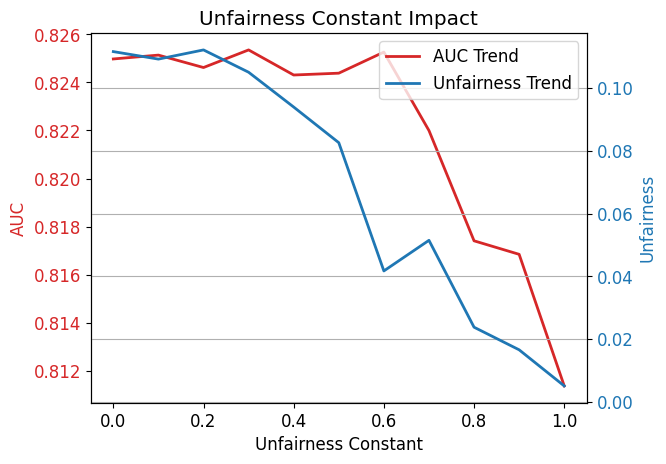

In [244]:
unfairness_constiemfairbpr_05 = []
unfairness_constiemfairbpr_000001 = []
unfairness_constiemfairbpr_00001 = []
unfairness_constiemfairbpr_0001 = []
unfairness_constiemfairbpr_001 = []
unfairness_constiemfairbpr_01 = []
unfairness_constiemfairbpr_02 = []
unfairness_constiemfairbpr_06 = []
unfairness_constiemfairbpr_07 = []
unfairness_constiemfairbpr_08 = []
unfairness_constiemfairbpr_09 = []


unfairness_constiemfairbpr_05.append((auc_perUserType_plot_constiemfairbpr[-1]['M']**2 - auc_perUserType_plot_constiemfairbpr[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_000001.append((auc_per_type_constiemfairadvbpr_000001[-1]['M']**2 - auc_per_type_constiemfairadvbpr_000001[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_00001.append((auc_per_type_constiemfairadvbpr_00001[-1]['M']**2 - auc_per_type_constiemfairadvbpr_00001[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_0001.append((auc_per_type_constiemfairadvbpr_0001[-1]['M']**2 - auc_per_type_constiemfairadvbpr_0001[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_001.append((auc_per_type_constiemfairadvbpr_001[-1]['M']**2 - auc_per_type_constiemfairadvbpr_001[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_01.append((auc_per_type_constiemfairadvbpr_01[-1]['M']**2 - auc_per_type_constiemfairadvbpr_01[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_02.append((auc_per_type_constiemfairadvbpr_02[-1]['M']**2 - auc_per_type_constiemfairadvbpr_02[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_06.append((auc_per_type_constiemfairadvbpr_06[-1]['M']**2 - auc_per_type_constiemfairadvbpr_06[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_07.append((auc_per_type_constiemfairadvbpr_07[-1]['M']**2 - auc_per_type_constiemfairadvbpr_07[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_08.append((auc_per_type_constiemfairadvbpr_08[-1]['M']**2 - auc_per_type_constiemfairadvbpr_08[-1]['F']**2)**2*100)
unfairness_constiemfairbpr_09.append((auc_per_type_constiemfairadvbpr_09[-1]['M']**2 - auc_per_type_constiemfairadvbpr_09[-1]['F']**2)**2*100)


def plotline_save_as_pdf4(title='',axis_x1 = None, xlabel = '', axis_y1 = None, axis_y2 = None, ylabel1 ='', ylabel2 ='', linewidth=2, plot_file = '',legendy1='', legendy2=''):
    
    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel1, color=color)
    if axis_y1 is not None:
        #plt.plot(axis_x1, axis_y1, 'b', linewidth = linewidth, label = legendy1)
        lns1 = ax1.plot(axis_x1, axis_y1, color=color, linewidth = linewidth, label = legendy1)
        ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.set_ylabel(ylabel2, color=color)  # we already handled the x-label with ax1
    
    if axis_y2 is not None:
       # plt.plot(axis_x1, axis_y2, 'red', linewidth = linewidth, label = legendy2)
        lns2 = ax2.plot(axis_x1, axis_y2, color=color, linewidth = linewidth, label = legendy2)
        ax2.tick_params(axis='y', labelcolor=color)

    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=0)
    plt.title(title)
    plt.grid()

    plt.savefig(plot_file)

plotline_save_as_pdf4(title='Unfairness Constant Impact',axis_x1 = np.arange(0,1.1,0.1), xlabel = 'Unfairness Constant', axis_y1 = [auc_constiemfairadvbpr_000001[-1], auc_constiemfairadvbpr_00001[-1], auc_constiemfairadvbpr_0001[-1], auc_constiemfairadvbpr_001[-1], auc_constiemfairadvbpr_01[-1], auc_constiemfairadvbpr_02[-1], auc_plot_constiemfairbpr[-1],auc_constiemfairadvbpr_06[-1], auc_constiemfairadvbpr_07[-1], auc_constiemfairadvbpr_08[-1], auc_constiemfairadvbpr_09[-1]], axis_y2 = [unfairness_constiemfairbpr_000001[-1], unfairness_constiemfairbpr_00001[-1], unfairness_constiemfairbpr_0001[-1], unfairness_constiemfairbpr_001[-1], unfairness_constiemfairbpr_01[-1], unfairness_constiemfairbpr_02[-1], unfairness_constiemfairbpr_05[-1],unfairness_constiemfairbpr_06[-1], unfairness_constiemfairbpr_07[-1], unfairness_constiemfairbpr_08[-1], unfairness_constiemfairbpr_09[-1]], ylabel1 ='AUC', ylabel2 ='Unfairness', linewidth=2, plot_file = './unfairBPR_plots/unfairness_const_impact_per_type.pdf',legendy1='AUC Trend', legendy2='Unfairness Trend')


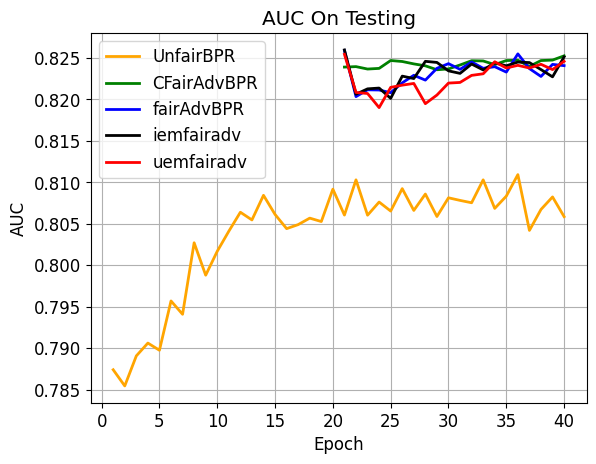

In [69]:
 plotline_save_as_pdf2(title='AUC On Testing',axis_x1 = range(1,40+1), axis_x2 = range(21,40+1), xlabel = 'Epoch', axis_y1 = auc_plot_unfairbpr, axis_y2 = auc_plot_constiemfairbpr , axis_y3 = auc_plot_fairadvbpr,axis_y4 = auc_plot_iemfairadvbpr,axis_y5 = auc_plot_uemfairadvbpr, ylabel ='AUC', linewidth=2, plot_file = './unfairBPR_plots/auc_all_methods.pdf',legendy1='UnfairBPR',legendy2='CFairAdvBPR',legendy3='fairAdvBPR',legendy4='iemfairadv',legendy5='uemfairadv')
 

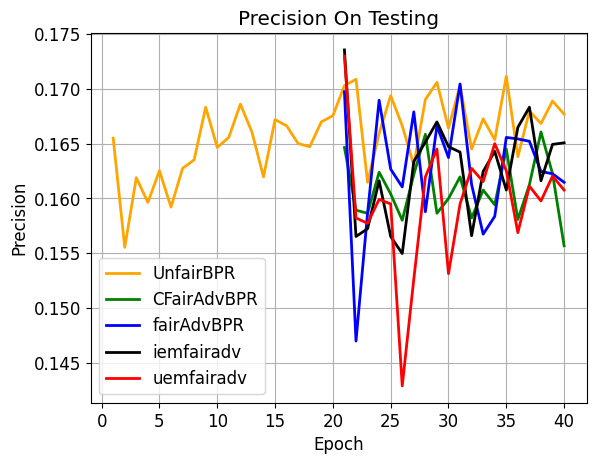

In [70]:
plotline_save_as_pdf2(title='Precision On Testing',axis_x1 = range(1,40+1), axis_x2 = range(21,40+1), xlabel = 'Epoch', axis_y1 = np.array(precision_plot_unfairbpr)[:,-1], axis_y2 = np.array(precision_plot_constiemfairbpr)[:,-1] , axis_y3 = np.array(precision_plot_fairadvbpr)[:,-1], axis_y4 = np.array(precision_plot_iemfairadvbpr)[:,-1], axis_y5 = np.array(precision_plot_uemfairadvbpr)[:,-1], ylabel ='Precision', linewidth=2, plot_file = './unfairBPR_plots/precisionat15_all_methods.pdf',legendy1='UnfairBPR',legendy2='CFairAdvBPR',legendy3='fairAdvBPR',legendy4='iemfairadv',legendy5='uemfairadv')
 

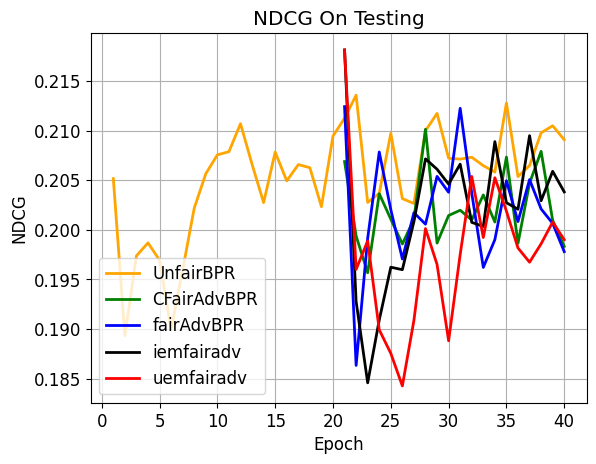

In [71]:
plotline_save_as_pdf2(title='NDCG On Testing',axis_x1 = range(1,40+1), axis_x2 = range(21,40+1), xlabel = 'Epoch', axis_y1 = np.array(ndcg_plot_unfairbpr)[:,-1], axis_y2 = np.array(ndcg_plot_constiemfairbpr)[:,-1] , axis_y3 = np.array(ndcg_plot_fairadvbpr)[:,-1], axis_y4 = np.array(ndcg_plot_iemfairadvbpr)[:,-1], axis_y5 = np.array(ndcg_plot_uemfairadvbpr)[:,-1], ylabel ='NDCG', linewidth=2, plot_file = './unfairBPR_plots/ndcgat15_all_methods.pdf',legendy1='UnfairBPR',legendy2='CFairAdvBPR',legendy3='fairAdvBPR',legendy4='iemfairadv',legendy5='uemfairadv')


In [72]:
#auc_plot_constiemfairbpr[-1]
#axis_y3 = [auc_perUserType_plot_unfairbpr[-1]['F'],auc_perUserType_plot_constiemfairbpr[-1]['F'],auc_perUserType_plot_fairadvbpr[-1]['F'],auc_perUserType_plot_iemfairadvbpr[-1]['F'],auc_perUserType_plot_uemfairadvbpr[-1]['F']]
#axis_y1 = [auc_plot_unfairbpr[-1],auc_plot_constiemfairbpr[-1],auc_plot_fairadvbpr[-1] ,auc_plot_iemfairadvbpr[-1], auc_plot_uemfairadvbpr[-1]]

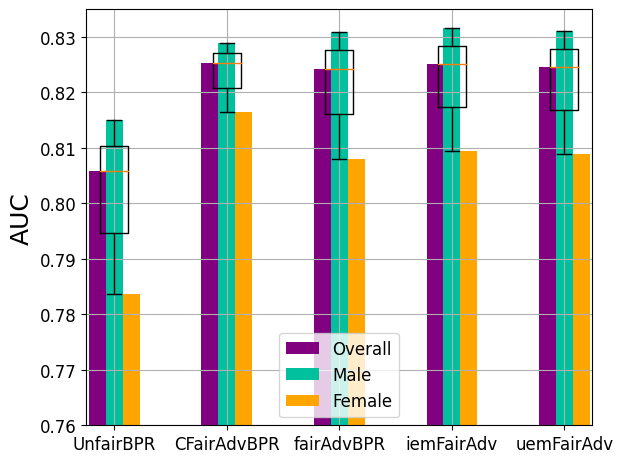

In [185]:

savepdf_barplot_color_gradient(ymin = 0.76, ymax = 0.835, start_color='purple',end_color='orange',num_color=3, title='AUC per User Type on Testing (Movielens)',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y1 = [auc_plot_unfairbpr[-1],auc_plot_constiemfairbpr[-1],auc_plot_fairadvbpr[-2] ,auc_plot_iemfairadvbpr[-1], auc_plot_uemfairadvbpr[-1]], axis_y2 = [auc_perUserType_plot_unfairbpr[-1]['M'],auc_perUserType_plot_constiemfairbpr[-1]['M'],auc_perUserType_plot_fairadvbpr[-2]['M'],auc_perUserType_plot_iemfairadvbpr[-1]['M'],auc_perUserType_plot_uemfairadvbpr[-1]['M']], axis_y3 = [auc_perUserType_plot_unfairbpr[-1]['F'],auc_perUserType_plot_constiemfairbpr[-1]['F'],auc_perUserType_plot_fairadvbpr[-2]['F'],auc_perUserType_plot_iemfairadvbpr[-1]['F'],auc_perUserType_plot_uemfairadvbpr[-1]['F']], ylabel ='AUC',barwidth = 0.3, plot_file = './unfairBPR_plots/auc_05_per_type.pdf',legendy1='Overall',legendy2='Male',legendy3='Female') 

In [224]:
unfairness_unfairbpr = []
unfairness_constiemfairbpr = []
unfairness_fairadvbpr = []
unfairness_iemfairadvbpr = []
unfairness_uemfairadvbpr = []

for i in range(len(auc_perUserType_plot_unfairbpr)):
    unfairness_unfairbpr.append((auc_perUserType_plot_unfairbpr[i]['M']**2 - auc_perUserType_plot_unfairbpr[i]['F']**2)**2*100)

for i in range(len(auc_perUserType_plot_constiemfairbpr)):
    unfairness_constiemfairbpr.append((auc_perUserType_plot_constiemfairbpr[i]['M']**2 - auc_perUserType_plot_constiemfairbpr[i]['F']**2)**2*100)

for i in range(len(auc_perUserType_plot_fairadvbpr)):
    unfairness_fairadvbpr.append((auc_perUserType_plot_fairadvbpr[i]['M']**2 - auc_perUserType_plot_fairadvbpr[i]['F']**2)**2*100)

for i in range(len(auc_perUserType_plot_iemfairadvbpr)):
    unfairness_iemfairadvbpr.append((auc_perUserType_plot_iemfairadvbpr[i]['M']**2 - auc_perUserType_plot_iemfairadvbpr[i]['F']**2)**2*100)
    
for i in range(len(auc_perUserType_plot_uemfairadvbpr)):
    unfairness_uemfairadvbpr.append((auc_perUserType_plot_uemfairadvbpr[i]['M']**2 - auc_perUserType_plot_uemfairadvbpr[i]['F']**2)**2*100)

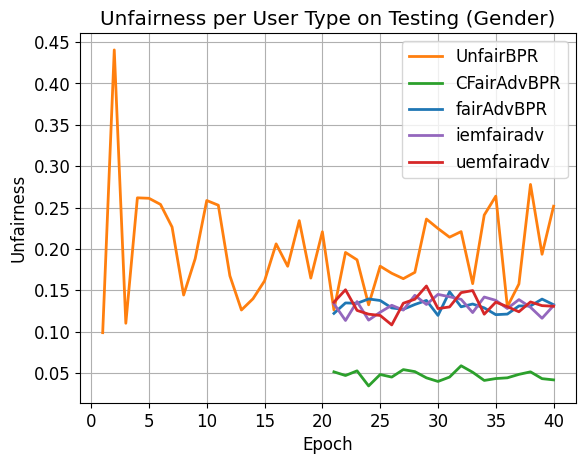

In [245]:
#savepdf_barplot_color_gradient3(ymin = 0.76, ymax = 0.835, title='Unfairness per User Type on Testing',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y = [auc_plot_unfairbpr[-1],auc_plot_constiemfairbpr[-1],auc_plot_fairadvbpr[-2] ,auc_plot_iemfairadvbpr[-1], auc_plot_uemfairadvbpr[-1]], ylabel ='Unfairness',barwidth = 0.3, plot_file = './unfairBPR_plots/unfairness_per_type.pdf')
plotline_save_as_pdf2(title='Unfairness per User Type on Testing (Gender)',axis_x1 = range(1,40+1), axis_x2 = range(21,40+1), xlabel = 'Epoch', axis_y1 = unfairness_unfairbpr, axis_y2 = unfairness_constiemfairbpr , axis_y3 = unfairness_fairadvbpr, axis_y4 = unfairness_iemfairadvbpr, axis_y5 = unfairness_uemfairadvbpr, ylabel ='Unfairness', linewidth=2, plot_file = './unfairBPR_plots/unfairness_per_type.pdf',legendy1='UnfairBPR',legendy2='CFairAdvBPR',legendy3='fairAdvBPR',legendy4='iemfairadv',legendy5='uemfairadv')


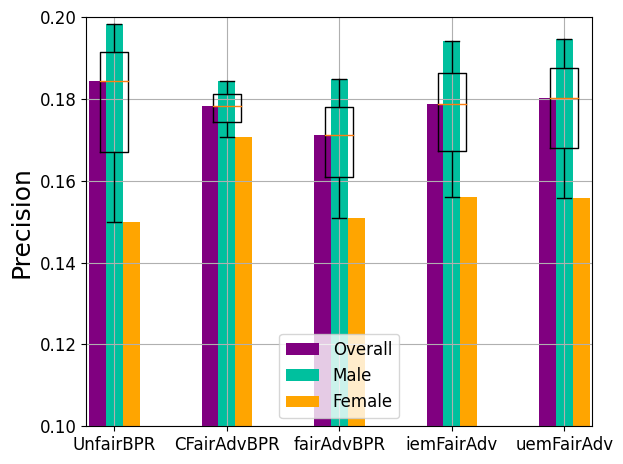

In [231]:
savepdf_barplot_color_gradient(ymin = 0.1, ymax = 0.2, start_color='purple',end_color='orange',num_color=3, title='Precision per User Type on Testing (Movielens)',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y1 = [precision_plot_unfairbpr[-1][2], precision_plot_constiemfairbpr[-10][2],precision_plot_fairadvbpr[-1][2] ,precision_plot_iemfairadvbpr[-1][2], precision_plot_uemfairadvbpr[-1][2]], axis_y2 = [precision_perUserType_plot_unfairbpr[-1]['M'][0].tolist()[2],precision_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[2],precision_perUserType_plot_fairadvbpr[-1]['M'][0].tolist()[2],precision_perUserType_plot_iemfairadvbpr[-1]['M'][0].tolist()[2],precision_perUserType_plot_uemfairadvbpr[-1]['M'][0].tolist()[2]], axis_y3 = [precision_perUserType_plot_unfairbpr[-1]['F'][0].tolist()[2], precision_perUserType_plot_constiemfairbpr[-10]['F'][0].tolist()[1],precision_perUserType_plot_fairadvbpr[-20]['F'][0].tolist()[2],precision_perUserType_plot_iemfairadvbpr[-20]['F'][0].tolist()[2],precision_perUserType_plot_uemfairadvbpr[-20]['F'][0].tolist()[2]], ylabel ='Precision',barwidth = 0.3, plot_file = './unfairBPR_plots/precision_05_per_type.pdf',legendy1='Overall',legendy2='Male',legendy3='Female') 

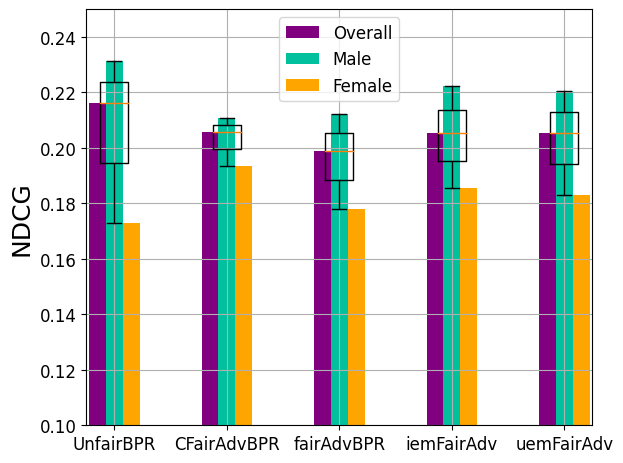

In [183]:
savepdf_barplot_color_gradient(ymin = 0.1, ymax = 0.25, start_color='purple',end_color='orange',num_color=3, title='NDCG per User Type on Testing (Movielens)',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y1 = [ndcg_plot_unfairbpr[-1][2],ndcg_plot_constiemfairbpr[1][2],ndcg_plot_fairadvbpr[-1][2] ,ndcg_plot_iemfairadvbpr[-1][2], ndcg_plot_uemfairadvbpr[-1][2]], axis_y2 = [ndcg_perUserType_plot_unfairbpr[-1]['M'][0].tolist()[2],ndcg_perUserType_plot_constiemfairbpr[1]['M'][0].tolist()[3],ndcg_perUserType_plot_fairadvbpr[-1]['M'][0].tolist()[2], ndcg_perUserType_plot_iemfairadvbpr[-1]['M'][0].tolist()[2],ndcg_perUserType_plot_uemfairadvbpr[-1]['M'][0].tolist()[2]], axis_y3 = [ndcg_perUserType_plot_unfairbpr[-1]['F'][0].tolist()[3], ndcg_perUserType_plot_constiemfairbpr[-20]['F'][0].tolist()[1],ndcg_perUserType_plot_fairadvbpr[-20]['F'][0].tolist()[2], ndcg_perUserType_plot_iemfairadvbpr[-20]['F'][0].tolist()[2], ndcg_perUserType_plot_uemfairadvbpr[-20]['F'][0].tolist()[2]], ylabel ='NDCG',barwidth = 0.3, plot_file = './unfairBPR_plots/ndcg_05_per_type.pdf',legendy1='Overall',legendy2='Male',legendy3='Female') 

In [79]:
precision_perUserType_plot_fairadvbpr[-1]

{'M': [array([0.27462687, 0.22119403, 0.18477612, 0.17323383])],
 'F': [array([0.23076923, 0.18315018, 0.13736264, 0.13260073])]}